<h1><center> Key Point Detection on CT Images <center></h1>

Data:
- https://www.kaggle.com/datasets/jiahongqian/cephalometric-landmarks?select=train_senior.csv

Two main steps of pipeline:
- train a encoder model to generate heatmaps
- find the coordinates of the key points from the heatmaps
- train a transformer model to improve the accuracy of the coordinates (is it prediction or regression?)

Concern: 
- the heatmap info is somehow lost in the transformer model, any interaction between the heatmap and the coordinates?

In [ ]:
!pip install einops
!pip install segmentation-models-pytorch

## 1. Basic Class/module from scratch

Not neccessary to figure out the details of the code, just to get a general idea of the pipeline. We can discuss the details later.

In [ ]:
import torch
import matplotlib.pyplot as plt
from torch import nn, einsum
from einops import rearrange

In [ ]:
def show2D(img):
    plt.imshow(img)
    plt.show()

def tensor2numpy(tensor):
    return tensor.data.cpu().numpy()

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.,):
        super().__init__()

        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim=-1)
        self.to_q = nn.Linear(dim, inner_dim, bias=False)
        self.to_k = nn.Linear(dim, inner_dim, bias=False)
        self.to_v = nn.Linear(dim, inner_dim, bias=False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, q_tokens, k_tokens=None, v_tokens=None):
        if k_tokens is None and v_tokens is None:
            v_tokens = k_tokens = q_tokens
        elif k_tokens is not None and v_tokens is not None:
            pass
        else:
            raise ValueError('k_tokens and v_tokens should be None or not simultaneously')

        q, k, v = [
            self.to_q(q_tokens),
            self.to_k(k_tokens),
            self.to_v(v_tokens),
        ]

        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)

        dots = einsum('b h i d, b h j d -> b h i j', q, k) * self.scale

        attn = self.attend(dots)
        out = einsum('b h i j, b h j d -> b h i d', attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out), attn

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, token_channels, heads=8, dim_head=64, channel_mlp=None, dropout=0., AddPosEmb2Value=True):
        super().__init__()
        if channel_mlp is None:
            channel_mlp = token_channels
        self.AddPosEmb2Value = AddPosEmb2Value

        self.norm1 = nn.LayerNorm(token_channels)
        self.Attention = MultiHeadAttention(token_channels, heads, dim_head, dropout)
        self.norm2 = nn.LayerNorm(token_channels)
        self.FFN = FeedForward(token_channels, channel_mlp, dropout=dropout)

    def forward(self, tokens, pos_embeddings=None):
        # pre norm
        q = k = v = self.norm1(tokens)

        # add pos_embeddings
        if pos_embeddings is not None:
            print('add pos_embeddings to q and k')
            q = q + pos_embeddings
            k = k + pos_embeddings
            if self.AddPosEmb2Value:
                print('add pos_embeddings to v')
                v = v + pos_embeddings

        # self attention
        attn_q, attn_map = self.Attention(q, k, v)  # attn_q has same shape with q

        # residual
        tokens = tokens + attn_q  # todo add token (which is not normed), not v !

        # norm
        q = self.norm2(tokens)

        # FFN
        ffn_q = self.FFN(q)

        # residual
        tokens = tokens + ffn_q  # todo add token (which is not normed), not v !

        return tokens, attn_map

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, token_channels, depth, heads, dim_head, mlp_dim=None, dropout=0.):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(
                token_channels,
                heads=heads,
                dim_head=dim_head,
                channel_mlp=mlp_dim,
                dropout=dropout,
                AddPosEmb2Value=False,
            ) for _ in range(depth)])

    def forward(self, tokens, pos_emb):
        attn_map_list = []
        for layer in self.layers:
            tokens, attention_maps = layer(tokens, pos_emb)
            attn_map_list.append(attention_maps)  # from shallow to deep
        return tokens, attn_map_list

## 2. Model for heatmap generation

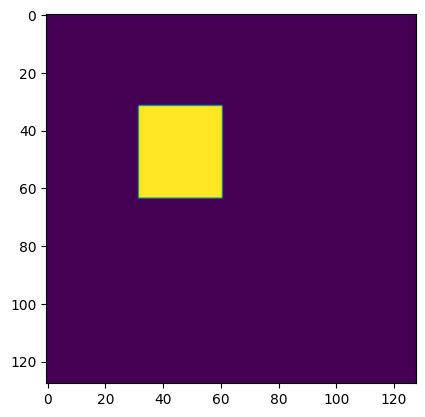

In [ ]:
## dummy data
keypoints_num = 20
image_channels = 1
batchsize = 2
input_image = torch.zeros([batchsize,image_channels,128,128])
input_image[:,:,32:64,32:61] = 1

show2D(tensor2numpy(torch.squeeze(input_image[0]))) # index 0 and 1 represent each batch

In [ ]:
# https://github.com/qubvel/segmentation_models.pytorch
# install segmentation-models-pytorch using pip or conda based on your environment

import segmentation_models_pytorch as smp

In [ ]:
model_heatmap = smp.Unet(
    encoder_name="resnet18",  # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",  # use `imagenet` pre-trained weights for encoder initialization
    in_channels=image_channels,  # model input channels (1 for gray-scale images*, 3 for RGB, etc.)
    classes=keypoints_num
)

In [ ]:
model_heatmap(input_image).shape

torch.Size([2, 20, 128, 128])

In [ ]:
kpy_heatmap = torch.sigmoid(model_heatmap(input_image))
print(kpy_heatmap.shape) # torch.Size([2, 10, 128, 128]) = batchsize, keypoints_num, height, width

torch.Size([2, 20, 128, 128])


In [ ]:
# after sigmoid, the heatmap is in the range of [0,1], the sum of dim=1 is 1
print(kpy_heatmap.sum(dim=1).shape) # torch.Size([2, 128, 128])
print(kpy_heatmap.sum(dim=1))
# why not sum up to 1?

torch.Size([2, 128, 128])
tensor([[[10.0695, 10.7283, 10.3528,  ..., 10.1874, 10.5327, 10.1288],
         [10.2241, 10.3610, 10.4560,  ..., 10.4695, 10.1288,  9.8179],
         [10.2939, 10.4068, 10.7085,  ..., 11.1847, 10.7670, 10.3996],
         ...,
         [10.3134, 10.3661, 10.4310,  ..., 10.1240, 10.9236, 11.0829],
         [10.1623, 10.3580, 10.1540,  ..., 10.1522, 10.6689, 10.6460],
         [10.0000, 10.3367, 10.3348,  ..., 10.3100, 10.5978, 10.4214]],

        [[10.0695, 10.7283, 10.3528,  ..., 10.1874, 10.5327, 10.1288],
         [10.2241, 10.3610, 10.4560,  ..., 10.4695, 10.1288,  9.8179],
         [10.2939, 10.4068, 10.7085,  ..., 11.1847, 10.7670, 10.3996],
         ...,
         [10.3134, 10.3661, 10.4310,  ..., 10.1240, 10.9236, 11.0829],
         [10.1623, 10.3580, 10.1540,  ..., 10.1522, 10.6689, 10.6460],
         [10.0000, 10.3367, 10.3348,  ..., 10.3100, 10.5978, 10.4214]]],
       grad_fn=<SumBackward1>)


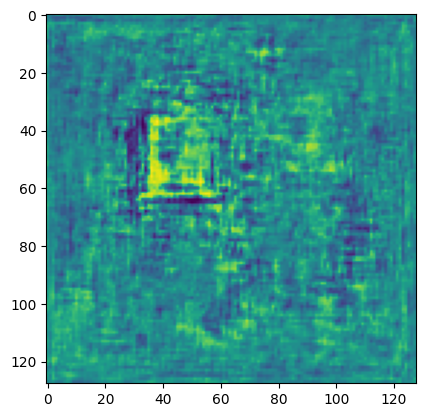

In [ ]:
# next we use above kpy_heatmap to obtain the coordinates of keypoints
show2D(tensor2numpy(torch.squeeze(kpy_heatmap[0,1])))

# ini_coordiate??? [..., 2] 2-dim: x y ==>numpy

## 3. Transformer model for coordinate refinement

I am not sure whether the transformer model is used for prediction or regression.

In [ ]:
# dummy data
kpts_coord_token = torch.ones([batchsize, keypoints_num, 2])  # 2 regards to x,y
print(kpts_coord_token.shape) # torch.Size([2, 19, 2])

torch.Size([2, 20, 2])


In [ ]:
# TransformerEncoder is the class we defined in section 1 above.
refinement_module = TransformerEncoder(
    token_channels=2,  # xy
    depth=2,
    heads=8,
    dim_head=128,
    mlp_dim=128,
)

In [ ]:
# perform refinement
refined_kpts_coord, _ = refinement_module(kpts_coord_token, pos_emb = None)

print(refined_kpts_coord.shape) # torch.Size([2, 19, 2])



torch.Size([2, 20, 2])
